In [6]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

# 1) Read data from CSV
df = pd.read_csv('2023_NBA_Stats (2).csv', sep='|')

# 2) Initialize the model
m = gp.Model("NBA_team")

# 3) Create a binary variable for each player
x = {}
for i in df.index:
    x[i] = m.addVar(vtype=GRB.BINARY, name=f"x_{i}")

# 4) Add constraints

# Constraint: Exactly 12 players
m.addConstr(
    gp.quicksum(x[i] for i in df.index) == 12,
    name="exactly_12"
)

# Constraint: Salary cap <= 190 million
m.addConstr(
    gp.quicksum(x[i] * df.loc[i, "salary"] for i in df.index) <= 190_000_000,
    name="salary_cap"
)

# Constraint: At least 3 guards (PG or SG)
m.addConstr(
    gp.quicksum(
        x[i]
        for i in df.index 
        if ("PG" in df.loc[i, "positions"]) or ("SG" in df.loc[i, "positions"])
    ) >= 3,
    name="min_guards"
)

# Constraint: At least 3 forwards (SF or PF)
m.addConstr(
    gp.quicksum(
        x[i]
        for i in df.index
        if ("SF" in df.loc[i, "positions"]) or ("PF" in df.loc[i, "positions"])
    ) >= 3,
    name="min_forwards"
)

# Constraint: At least 1 center (C)
m.addConstr(
    gp.quicksum(
        x[i]
        for i in df.index
        if ("C" in df.loc[i, "positions"])
    ) >= 1,
    name="min_centers"
)

# 5) Objective: Maximize total Relative Value
m.setObjective(
    gp.quicksum(x[i] * df.loc[i, "relative_value"] for i in df.index),
    GRB.MAXIMIZE
)

# 6) Solve the optimization problem
m.optimize()

# 7) Identify the chosen players
chosen_indices = [i for i in df.index if x[i].X > 0.5]

# 8) Print and summarize results
print("Optimal Team Selection:")
print("=======================")
selected_players = df.loc[chosen_indices, ["player_name", "positions", "salary", "relative_value"]]
print(selected_players)

total_salary = selected_players["salary"].sum()
total_rel_value = selected_players["relative_value"].sum()

print("-----------------------")
print(f"Total salary:        ${total_salary:,.0f}")
print(f"Total relative value: {total_rel_value:.2f}")


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 5 rows, 474 columns and 1572 nonzeros


Model fingerprint: 0xa0e99358
Variable types: 0 continuous, 474 integer (474 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+07]
  Objective range  [7e-03, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+08]
Found heuristic solution: objective -5.9156327
Presolve time: 0.00s
Presolved: 5 rows, 474 columns, 1572 nonzeros
Variable types: 0 continuous, 474 integer (474 binary)

Root relaxation: objective 1.446846e+02, 4 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  144.68464    0    2   -5.91563  144.68464  2546%     -    0s
H    0     0                     144.1566158  144.68464  0.37%     -    0s
H    0     0                     144.3109737  144.68464  0.26%     -    0s
     0     0  144.68464    0    2  144.31097  144.68464  0.26%     -    0s

Explored 1 nodes (4 simplex iterations) in 0.0

### Diffrent code, using diffrent model, nevertheless outcome is the same

In [ ]:
import pandas as pd
from gurobipy import Model, GRB

# 1) Read the dataset
df = pd.read_csv("2023_NBA_Stats.csv")

# 2) Parse relevant data fields
players = df["player_name"].tolist()
positions = df["positions"].tolist()
salaries = df["salary"].tolist()
rel_values = df["relative_value"].tolist()

num_players = len(players)

# 3) Determine eligibility for Guards, Forwards, and Centers
is_guard = []
is_forward = []
is_center = []

for pos_str in positions:
    pos_list = [p.strip() for p in pos_str.split(",")]
    guard_flag = any(p in ["PG", "SG"] for p in pos_list)
    forward_flag = any(p in ["SF", "PF"] for p in pos_list)
    center_flag = any(p in ["C"] for p in pos_list)
    
    is_guard.append(guard_flag)
    is_forward.append(forward_flag)
    is_center.append(center_flag)

# 4) Build the Gurobi model
m = Model("NBA_Team_Selection")

#    Create binary decision variables x_i
x = m.addVars(num_players, vtype=GRB.BINARY, name="x")

# 5) Add constraints

# (a) Exactly 12 players
m.addConstr(x.sum('*') == 12, name="Exactly_12_Players")

n = [10000000, 20000000, 30000000, 40000000, 50000000, 60000000, 70000000, 80000000, 90000000, 100000000, 110000000, 120000000, 130000000, 140000000, 150000000, 160000000, 170000000, 180000000, 190000000]
# (b) Salary cap
m.addConstr(
    sum(salaries[i] * x[i] for i in range(num_players)) <= n[i],
    name="Salary_Cap"
)

# (c) At least 3 guards
m.addConstr(
    sum(x[i] for i in range(num_players) if is_guard[i]) >= 3,
    name="At_Least_3_Guards"
)

# (d) At least 3 forwards
m.addConstr(
    sum(x[i] for i in range(num_players) if is_forward[i]) >= 3,
    name="At_Least_3_Forwards"
)

# (e) At least 1 center
m.addConstr(
    sum(x[i] for i in range(num_players) if is_center[i]) >= 1,
    name="At_Least_1_Center"
)

# 6) Objective: maximize total relative value
m.setObjective(
    sum(rel_values[i] * x[i] for i in range(num_players)),
    GRB.MAXIMIZE
)

# 7) Solve the model
m.optimize()

# 8) Print the results
if m.status == GRB.OPTIMAL:
    print(f"Optimal total relative value: {m.objVal:.3f}\n")
    
    selected_players = []
    for i in range(num_players):
        if x[i].X > 0.5:  # x[i] = 1 if the player is selected
            selected_players.append(
                (players[i], positions[i], salaries[i], rel_values[i])
            )
    
    # Optional: Sort selected players by relative value descending
    selected_players.sort(key=lambda p: p[3], reverse=True)
    
    print("Selected Team (12 players):")
    for p in selected_players:
        print(f" - {p[0]} | Positions: {p[1]} | Salary: ${p[2]:,} | Rel. Value: {p[3]}")

    # Calculate and print total salary
    total_salary = sum(p[2] for p in selected_players)
    print(f"\nTotal Salary: ${total_salary:,.0f}")
    
else:
    print("No optimal solution found. Status code:", m.status)


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 5 rows, 474 columns and 1516 nonzeros
Model fingerprint: 0x96376549
Variable types: 0 continuous, 474 integer (474 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+07]
  Objective range  [7e-03, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+08]
Found heuristic solution: objective -5.9156327
Presolve added 1 rows and 1 columns
Presolve time: 0.00s
Presolved: 6 rows, 475 columns, 1334 nonzeros
Variable types: 0 continuous, 475 integer (474 binary)

Root relaxation: objective 1.446846e+02, 4 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 

Set parameter Username
Set parameter LicenseID to value 2616646
Academic license - for non-commercial use only - expires 2026-01-30


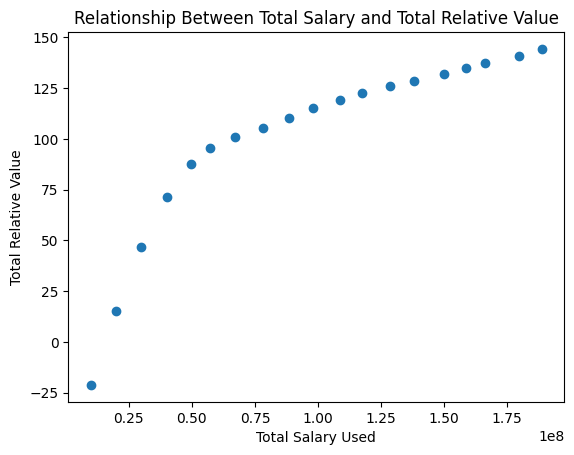

Cap Allowed |  Salary Used  |  Relative Value  |  Status
----------- |  ------------ |  ---------------  |  ------
 10,000,000 |    9,970,176 |         -21.244 | 2
 20,000,000 |   19,986,255 |          15.306 | 2
 30,000,000 |   29,986,982 |          46.471 | 2
 40,000,000 |   39,987,282 |          71.393 | 2
 50,000,000 |   49,653,352 |          87.407 | 2
 60,000,000 |   57,113,992 |          95.657 | 2
 70,000,000 |   67,208,087 |         101.053 | 2
 80,000,000 |   78,033,055 |         105.238 | 2
 90,000,000 |   88,434,257 |         110.223 | 2
100,000,000 |   97,885,088 |         115.314 | 2
110,000,000 |  108,588,745 |         119.169 | 2
120,000,000 |  117,480,145 |         122.678 | 2
130,000,000 |  128,356,465 |         125.855 | 2
140,000,000 |  137,921,465 |         128.439 | 2
150,000,000 |  149,825,158 |         131.729 | 2
160,000,000 |  158,726,688 |         134.879 | 2
170,000,000 |  166,119,545 |         137.166 | 2
180,000,000 |  179,750,758 |         140.848 | 2
190

In [2]:
import pandas as pd
from gurobipy import Model, GRB
import matplotlib.pyplot as plt

# 1) Read the dataset
df = pd.read_csv("2023_NBA_Stats.csv")

# 2) Extract relevant data
players = df["player_name"].tolist()
positions = df["positions"].tolist()
salaries = df["salary"].tolist()
rel_values = df["relative_value"].tolist()
num_players = len(players)

# 3) Determine eligibility for Guards, Forwards, and Centers
is_guard = []
is_forward = []
is_center = []

for pos_str in positions:
    pos_list = [p.strip() for p in pos_str.split(",")]
    guard_flag = any(p in ["PG", "SG"] for p in pos_list)
    forward_flag = any(p in ["SF", "PF"] for p in pos_list)
    center_flag = any(p in ["C"] for p in pos_list)
    
    is_guard.append(guard_flag)
    is_forward.append(forward_flag)
    is_center.append(center_flag)

def solve_with_cap(cap_amount):
    """
    Builds and solves the model with a given salary cap,
    returns (total_salary_used, total_rel_value, status).
    """
    m = Model("NBA_Team_Selection")
    x = m.addVars(num_players, vtype=GRB.BINARY, name="x")
    
    # Constraints
    m.addConstr(x.sum('*') == 12, name="Exactly_12_Players")
    m.addConstr(sum(salaries[i]*x[i] for i in range(num_players)) <= cap_amount,
                name="Salary_Cap")
    m.addConstr(sum(x[i] for i in range(num_players) if is_guard[i]) >= 3,
                name="At_Least_3_Guards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_forward[i]) >= 3,
                name="At_Least_3_Forwards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_center[i]) >= 1,
                name="At_Least_1_Center")
    
    # Objective
    m.setObjective(
        sum(rel_values[i] * x[i] for i in range(num_players)),
        GRB.MAXIMIZE
    )
    m.setParam('OutputFlag', 0)  # turn off Gurobi console output for clarity
    m.optimize()
    
    if m.status == GRB.OPTIMAL:
        # Collect which players are chosen
        chosen_indices = [i for i in range(num_players) if x[i].X > 0.5]
        total_salary_used = sum(salaries[i] for i in chosen_indices)
        total_rel_value = sum(rel_values[i] for i in chosen_indices)
        return total_salary_used, total_rel_value, m.status
    else:
        return 0, 0, m.status

# 4) Test different salary caps from 10M to 190M, in increments of 10M
caps = range(10_000_000, 190_000_001, 10_000_000)

results = []
for cap in caps:
    total_salary_used, total_rel_value, status = solve_with_cap(cap)
    # Store the actual used salary and the objective value
    results.append((cap, total_salary_used, total_rel_value, status))

# 5) Create lists for plotting:
#    We want to plot "total salary used" (x-axis) vs. "total relative value" (y-axis).
#    Note that "cap" is the *allowed* max, but "total_salary_used" is what the solver *actually* uses.
x_vals = []
y_vals = []
for cap, used_sal, rel_val, stat in results:
    if stat == GRB.OPTIMAL:
        x_vals.append(used_sal)
        y_vals.append(rel_val)
    else:
        # If it's infeasible or not optimal for any reason, you could skip or store 0
        x_vals.append(used_sal)
        y_vals.append(rel_val)

# 6) Plot the results
plt.figure()
plt.scatter(x_vals, y_vals)
plt.xlabel("Total Salary Used")
plt.ylabel("Total Relative Value")
plt.title("Relationship Between Total Salary and Total Relative Value")
plt.show()

# 7) (Optional) Print a small table of results
print("Cap Allowed |  Salary Used  |  Relative Value  |  Status")
print("----------- |  ------------ |  ---------------  |  ------")
for cap, used_sal, rel_val, stat in results:
    print(f"{cap:11,d} | {used_sal:12,.0f} | {rel_val:15,.3f} | {stat}")


In [ ]:
import pandas as pd
import random
from gurobipy import Model, GRB
import math

df = pd.read_csv("2023_NBA_Stats.csv")

players   = df["player_name"].tolist()
positions = df["positions"].tolist()
salaries  = df["salary"].tolist()

num_players = len(players)

is_guard   = []
is_forward = []
is_center  = []

for pos_str in positions:
    pos_list = [p.strip() for p in pos_str.split(",")]
    guard_flag   = any(p in ["PG", "SG"] for p in pos_list)
    forward_flag = any(p in ["SF", "PF"] for p in pos_list)
    center_flag  = any(p in ["C"]        for p in pos_list)
    
    is_guard.append(guard_flag)
    is_forward.append(forward_flag)
    is_center.append(center_flag)

random_rel_values = [random.uniform(-15, 15) for _ in range(num_players)]


def build_and_solve(cap=190_000_000, rel_values=None):
    """Builds the Gurobi model and solves for the best team given constraints."""
    m = Model("NBA_Team_Selection")

    x = m.addVars(num_players, vtype=GRB.BINARY, name="x")

    m.addConstr(x.sum('*') == 12, name="Exactly_12_Players")
    m.addConstr(sum(salaries[i]*x[i] for i in range(num_players)) <= cap, "Salary_Cap")
    m.addConstr(sum(x[i] for i in range(num_players) if is_guard[i]) >= 3, "Min_Guards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_forward[i]) >= 3, "Min_Forwards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_center[i]) >= 1, "Min_Centers")
    
    m.setObjective(sum(rel_values[i] * x[i] for i in range(num_players)), GRB.MAXIMIZE)
    
    m.setParam('OutputFlag', 0)
    m.optimize()
    
    if m.status == GRB.OPTIMAL:
        chosen_indices = [i for i in range(num_players) if x[i].X > 0.5]
        total_salary   = sum(salaries[i] for i in chosen_indices)
        total_rel_val  = sum(rel_values[i] for i in chosen_indices)
        return m, chosen_indices, total_salary, total_rel_val
    else:
        return None, [], 0, 0

model, chosen_team, used_salary, best_rel_val = build_and_solve(
    cap=190_000_000, 
    rel_values=random_rel_values
)

if model is None:
    print("No feasible solution found under these constraints.")
else:
    print(f"Found an optimal team of 12 players with random relative values!")
    print(f"Objective (Total Relative Value): {best_rel_val:.3f}")
    print(f"Salary Used: ${used_salary:,.0f}\n")
    
    chosen_players_data = []
    for i in chosen_team:
        chosen_players_data.append(
            (players[i], positions[i], salaries[i], random_rel_values[i])
        )
    chosen_players_data.sort(key=lambda x: x[3], reverse=True)
    
    print("Chosen Team (Name | Positions | Salary | Random Rel. Value)")
    for p in chosen_players_data:
        print(f" - {p[0]} | {p[1]} | ${p[2]:,} | {p[3]:.2f}")


    alternatives_found = []
    eps = 1e-5  
    
    for i_out in chosen_team:
        m_alt = Model("NBA_Alternate")
        x_alt = m_alt.addVars(num_players, vtype=GRB.BINARY, name="x_alt")
        
        m_alt.addConstr(x_alt.sum('*') == 12)
        m_alt.addConstr(sum(salaries[j]*x_alt[j] for j in range(num_players)) <= 190_000_000)
        m_alt.addConstr(sum(x_alt[j] for j in range(num_players) if is_guard[j]) >= 3)
        m_alt.addConstr(sum(x_alt[j] for j in range(num_players) if is_forward[j]) >= 3)
        m_alt.addConstr(sum(x_alt[j] for j in range(num_players) if is_center[j]) >= 1)
        
        m_alt.addConstr(x_alt[i_out] == 0, name="Force_out_chosen_player")
        
        m_alt.setObjective(sum(random_rel_values[j] * x_alt[j] for j in range(num_players)),
                           GRB.MAXIMIZE)
        
        m_alt.setParam('OutputFlag', 0)
        m_alt.optimize()
        
        if m_alt.status == GRB.OPTIMAL:
            alt_obj_val = m_alt.objVal
            if alt_obj_val >= best_rel_val - eps:
                alt_team = [j for j in range(num_players) if x_alt[j].X > 0.5]
                alt_salary = sum(salaries[j] for j in alt_team)
                removed_player_name = players[i_out]
                alt_player_names = [players[j] for j in alt_team]
                
                alternatives_found.append(
                    {
                        "removed_player": removed_player_name,
                        "obj_val": alt_obj_val,
                        "salary": alt_salary,
                        "team_indices": alt_team,
                        "team_names": alt_player_names
                    }
                )

    if alternatives_found:
        print("\nPossible ways to change the team while maintaining optimal relative value:")
        for alt in alternatives_found:
            print(f"\nRemoved player: {alt['removed_player']}")
            print(f"Alternative objective: {alt['obj_val']:.2f}, Salary Used: ${alt['salary']:.0f}")
            print("New Team Roster:")
            for name in alt['team_names']:
                print(f"   - {name}")
    else:
        print("\nNo single-player swap found that still maintains the same objective value.")


Found an optimal team of 12 players with random relative values!
Objective (Total Relative Value): 175.473
Salary Used: $154,265,166

Chosen Team (Name | Positions | Salary | Random Rel. Value)
 - Chris Paul | PG | $30,800,000 | 14.99
 - Ayo Dosunmu | SG | $6,481,482 | 14.94
 - Pascal Siakam | PF,FC | $37,893,408 | 14.89
 - Bobby Portis | PF,FC | $11,710,818 | 14.88
 - Admiral Schofield | SF,PF | $506,508 | 14.71
 - Jalen Green | PG,SG | $9,891,480 | 14.67
 - Immanuel Quickley | PG,SG | $4,171,548 | 14.62
 - Fred VanVleet | PG | $40,806,300 | 14.46
 - Walker Kessler | C | $2,831,160 | 14.44
 - Devin Vassell | SG,SF | $5,887,899 | 14.38
 - Bol Bol | PF,FC | $2,165,000 | 14.35
 - Jacob Toppin | SF | $1,119,563 | 14.15

No single-player swap found that still maintains the same objective value.


In [ ]:
import pandas as pd
import random
from gurobipy import Model, GRB

df = pd.read_csv("2023_NBA_Stats.csv")

players   = df["player_name"].tolist()
positions = df["positions"].tolist()
salaries  = df["salary"].tolist()
rel_values_week1 = df["relative_value"].tolist()  

num_players = len(players)

is_guard   = []
is_forward = []
is_center  = []

for pos_str in positions:
    pos_list = [p.strip() for p in pos_str.split(",")]
    guard_flag   = any(p in ["PG", "SG"] for p in pos_list)
    forward_flag = any(p in ["SF", "PF"] for p in pos_list)
    center_flag  = any(p == "C"           for p in pos_list)

    is_guard.append(guard_flag)
    is_forward.append(forward_flag)
    is_center.append(center_flag)

def solve_week1(cap=190_000_000):
    """
    Solve the initial problem for Week 1 with the CSV's relative values.
    """
    m = Model("NBA_Week1_Selection")
    x = m.addVars(num_players, vtype=GRB.BINARY, name="x")

    m.addConstr(x.sum('*') == 12, "Exactly_12")
    m.addConstr(sum(salaries[i]*x[i] for i in range(num_players)) <= cap, "Salary_Cap")
    m.addConstr(sum(x[i] for i in range(num_players) if is_guard[i]) >= 3, "Min_Guards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_forward[i]) >= 3, "Min_Forwards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_center[i]) >= 1, "Min_Centers")

    m.setObjective(sum(rel_values_week1[i] * x[i] for i in range(num_players)), GRB.MAXIMIZE)

    m.setParam('OutputFlag', 0)
    m.optimize()

    chosen_indices = []
    if m.status == GRB.OPTIMAL:
        chosen_indices = [i for i in range(num_players) if x[i].X > 0.5]

    return m, chosen_indices

week1_model, week1_team = solve_week1(cap=190_000_000)

if week1_model.status == GRB.OPTIMAL:
    week1_obj_val = week1_model.objVal
    print("=== WEEK 1 RESULTS (from CSV Relative Values) ===")
    print(f"Optimal total relative value (Week 1): {week1_obj_val:.3f}")
    chosen_week1_players = []
    for i in week1_team:
        chosen_week1_players.append(
            (players[i], positions[i], salaries[i], rel_values_week1[i])
        )
    chosen_week1_players.sort(key=lambda p: p[3], reverse=True)

    total_salary_week1 = sum(p[2] for p in chosen_week1_players)
    print(f"Total Salary: ${total_salary_week1:,.0f}")
    print("Chosen Team (Week 1):")
    for p in chosen_week1_players:
        print(f" - {p[0]} | {p[1]} | Salary: ${p[2]:,} | Rel. Value: {p[3]:.2f}")
    print("================================================\n")

else:
    print("No feasible solution for Week 1.")
    raise SystemExit


rel_values_week2 = [random.uniform(-2, 10) for _ in range(num_players)]



def solve_week2(cap=190_000_000, old_team_indices=None):
    """
    Solve for Week 2 under the constraints:
      - Up to 4 players can differ from the old team
      - Must still have 12 players, <= $190M, position mins
      - Objective: maximize sum of new random relative values
    """
    m = Model("NBA_Week2_Selection")
    x = m.addVars(num_players, vtype=GRB.BINARY, name="x2")

    m.addConstr(x.sum('*') == 12, "Exactly_12")
    m.addConstr(sum(salaries[i]*x[i] for i in range(num_players)) <= cap, "Salary_Cap")
    m.addConstr(sum(x[i] for i in range(num_players) if is_guard[i]) >= 3, "Min_Guards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_forward[i]) >= 3, "Min_Forwards")
    m.addConstr(sum(x[i] for i in range(num_players) if is_center[i]) >= 1, "Min_Centers")

    old_team_vector = [0]*num_players
    for j in old_team_indices:
        old_team_vector[j] = 1

    m.addConstr(
        sum(x[i]*(1 - old_team_vector[i]) + (1 - x[i])*old_team_vector[i] for i in range(num_players)) 
        <= 4,
        "Max_4_Changes"
    )

    m.setObjective(sum(rel_values_week2[i]*x[i] for i in range(num_players)), GRB.MAXIMIZE)

    m.setParam('OutputFlag', 0)
    m.optimize()

    chosen_indices = []
    if m.status == GRB.OPTIMAL:
        chosen_indices = [i for i in range(num_players) if x[i].X > 0.5]

    return m, chosen_indices

week2_model, week2_team = solve_week2(cap=190_000_000, old_team_indices=week1_team)

if week2_model.status == GRB.OPTIMAL:
    week2_obj_val = week2_model.objVal
    print("=== WEEK 2 RESULTS (Random Relative Values) ===")
    print(f"Optimal total relative value (Week 2): {week2_obj_val:.3f}")

    chosen_week2_players = []
    for i in week2_team:
        chosen_week2_players.append(
            (players[i], positions[i], salaries[i], rel_values_week2[i])
        )
    chosen_week2_players.sort(key=lambda p: p[3], reverse=True)

    total_salary_week2 = sum(p[2] for p in chosen_week2_players)
    print(f"Total Salary: ${total_salary_week2:,.0f}")
    print("Chosen Team (Week 2):")
    for p in chosen_week2_players:
        print(f" - {p[0]} | {p[1]} | Salary: ${p[2]:,} | Rel. Value: {p[3]:.2f}")

    old_set = set(week1_team)
    new_set = set(week2_team)
    changed = (old_set ^ new_set) 
    print(f"\nNumber of changes from Week 1 to Week 2: {len(changed)} (should be <= 4)")
    print("================================================")
else:
    print("No feasible solution for Week 2 with the 4-swap constraint.")


=== WEEK 1 RESULTS (from CSV Relative Values) ===
Optimal total relative value (Week 1): 144.311
Total Salary: $188,726,895
Chosen Team (Week 1):
 - Shai Gilgeous-Alexander | PG,SG | Salary: $33,386,850 | Rel. Value: 18.73
 - Nikola Jokic | C | Salary: $47,607,350 | Rel. Value: 18.09
 - Anthony Davis | PF,FC | Salary: $40,600,080 | Rel. Value: 17.22
 - Tyrese Haliburton | PG,SG | Salary: $5,808,435 | Rel. Value: 13.58
 - Scottie Barnes | SG,SF,PF | Salary: $8,008,680 | Rel. Value: 12.70
 - Chet Holmgren | PF,FC | Salary: $10,386,000 | Rel. Value: 11.64
 - Tyrese Maxey | PG,SG | Salary: $4,343,920 | Rel. Value: 9.57
 - Victor Wembanyama | PF,FC | Salary: $12,160,680 | Rel. Value: 9.56
 - Desmond Bane | SG,SF | Salary: $3,845,083 | Rel. Value: 9.37
 - Anthony Edwards | SG,SF | Salary: $13,534,817 | Rel. Value: 8.65
 - Franz Wagner | SG,SF,PF | Salary: $5,508,720 | Rel. Value: 7.63
 - Alperen Sengun | C | Salary: $3,536,280 | Rel. Value: 7.57

=== WEEK 2 RESULTS (Random Relative Values) =